🔹 STEP 1 — DATA LOADING & DATA ANALYSIS


Step 1.1 — Load Dataset in Colab

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/battery_degradation.csv')

# Show first 5 rows
df.head()


,charge_cycles,avg_temperature_c,battery_type,charge_rate,discharge_depth,battery_age_months,voltage_variation,cooling_system,manufacturer,usage_pattern,capacity_remaining_percent
0,994.0,15.749784,Li-ion,Superfast,83.043118,30.0,4.129414,NaN,E,Performance,87.278537
1,NaN,NaN,Li-Po,Medium,62.135883,29.0,1.045002,Passive,D,Highway,55.291610
2,121.0,38.216794,Li-ion,Superfast,95.555966,10.0,1.709691,Passive,E,Performance,52.580032
3,427.0,38.713143,NaN,Superfast,67.144652,53.0,1.963543,Active,E,Performance,69.824669
4,1569.0,37.040177,NaN,Slow,61.831927,32.0,4.823389,NaN,E,Highway,NaN


Step 1.2 — Check Dataset Shape (rows × columns)

In [2]:
df.shape


(1000, 11)

Step 1.3 — Column Names

In [3]:
df.columns


Index(['charge_cycles', 'avg_temperature_c', 'battery_type', 'charge_rate',
       'discharge_depth', 'battery_age_months', 'voltage_variation',
       'cooling_system', 'manufacturer', 'usage_pattern',
       'capacity_remaining_percent'],
      dtype='object')

Step 1.4 — Dataset Information

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   charge_cycles               942 non-null    float64
 1   avg_temperature_c           940 non-null    float64
 2   battery_type                955 non-null    object 
 3   charge_rate                 942 non-null    object 
 4   discharge_depth             943 non-null    float64
 5   battery_age_months          962 non-null    float64
 6   voltage_variation           945 non-null    float64
 7   cooling_system              652 non-null    object 
 8   manufacturer                949 non-null    object 
 9   usage_pattern               955 non-null    object 
 10  capacity_remaining_percent  951 non-null    float64
dtypes: float64(6), object(5)
memory usage: 86.1+ KB


Step 1.5 — Statistical Summary

In [5]:
df.describe()


,charge_cycles,avg_temperature_c,discharge_depth,battery_age_months,voltage_variation,capacity_remaining_percent
count,942.000000,940.000000,943.000000,962.000000,945.000000,951.000000
mean,1053.684713,29.840542,59.926519,29.771310,2.775223,76.207402
std,549.423662,8.752206,23.211115,17.117811,1.319354,15.018244
min,50.000000,15.017843,20.148317,1.000000,0.500075,50.100057
25%,584.000000,22.473228,40.104128,15.000000,1.614787,62.750708
50%,1063.000000,29.683332,59.656375,29.000000,2.776916,76.275186
75%,1513.750000,37.412412,80.877091,45.000000,3.924650,89.778058
max,1997.000000,44.947042,99.783801,59.000000,4.995995,101.898529


STEP 2 — MISSING VALUE ANALYSIS & DATA IMPUTATION

Step 2.1 — Check Missing Values

In [6]:
df.isnull().sum()


,0
charge_cycles,58
avg_temperature_c,60
battery_type,45
charge_rate,58
discharge_depth,57
battery_age_months,38
voltage_variation,55
cooling_system,348
manufacturer,51
usage_pattern,45


Step 2.2 — Visualize Missing Values (Optional but Good Practice)

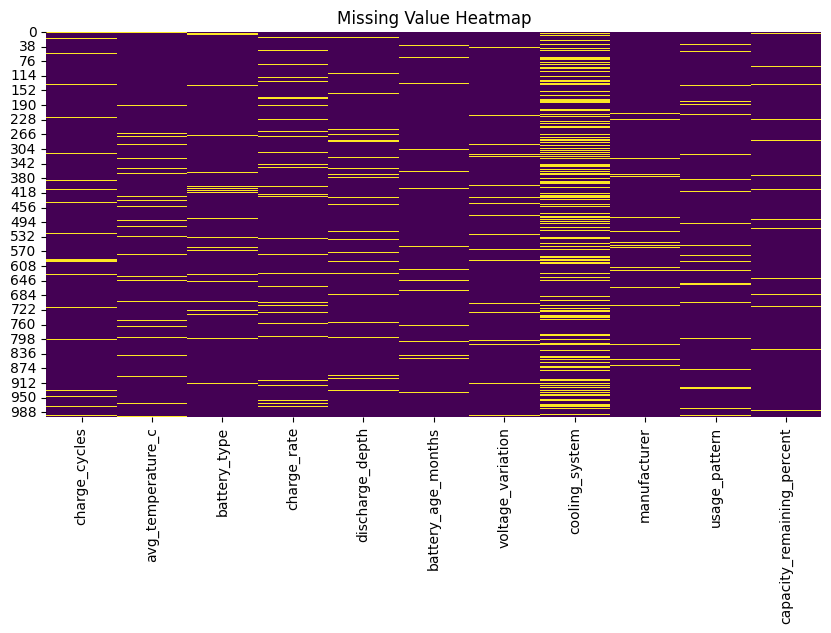

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()


Step 2.3 — Identify Numeric Columns

In [9]:
df.select_dtypes(include=['int64','float64']).columns


Index(['charge_cycles', 'avg_temperature_c', 'discharge_depth',
       'battery_age_months', 'voltage_variation',
       'capacity_remaining_percent'],
      dtype='object')

Step 2.4 — Apply Mean Imputation ONLY on Numeric Columns

In [10]:
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=['int64','float64']).columns

imputer = SimpleImputer(strategy='mean')
df[num_cols] = imputer.fit_transform(df[num_cols])


Step 2.5 — Verify Missing Values Again

In [11]:
df.isnull().sum()


,0
charge_cycles,0
avg_temperature_c,0
battery_type,45
charge_rate,58
discharge_depth,0
battery_age_months,0
voltage_variation,0
cooling_system,348
manufacturer,51
usage_pattern,45


Step 2.6 — Find Categorical Columns

In [12]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols


Index(['battery_type', 'charge_rate', 'cooling_system', 'manufacturer',
       'usage_pattern'],
      dtype='object')

Step 2.7 — Fill Missing Values using MOST FREQUENT

In [13]:
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


Step 2.8 — Final Missing Value Check

In [14]:
df.isnull().sum()


,0
charge_cycles,0
avg_temperature_c,0
battery_type,0
charge_rate,0
discharge_depth,0
battery_age_months,0
voltage_variation,0
cooling_system,0
manufacturer,0
usage_pattern,0


STEP 3 — EDA (EXPLORATORY DATA ANALYSIS) & DATA VISUALIZATION 📊

Step 3.1 — Basic Visual Understanding of Data
Distribution of Battery Capacity (Target Variable)

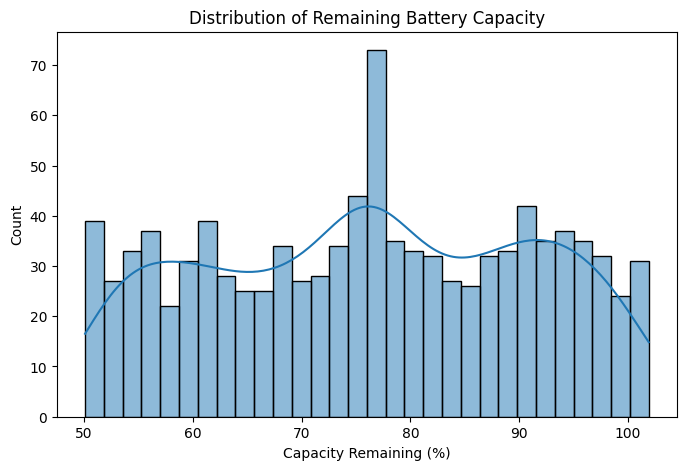

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['capacity_remaining_percent'], bins=30, kde=True)
plt.title("Distribution of Remaining Battery Capacity")
plt.xlabel("Capacity Remaining (%)")
plt.ylabel("Count")
plt.show()


Step 3.2 — Charge Cycles vs Battery Degradation

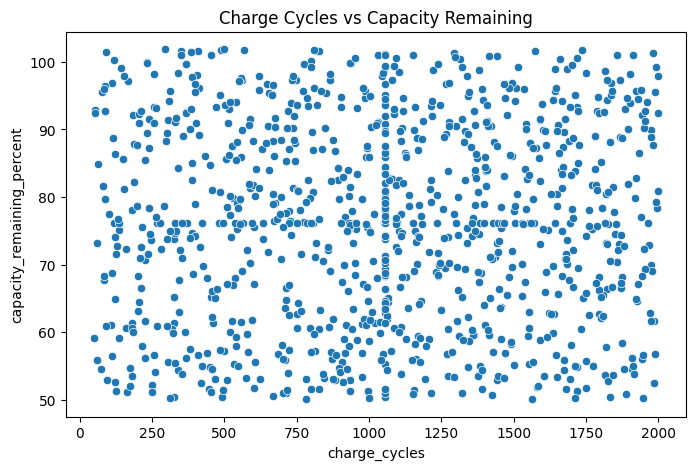

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='charge_cycles', y='capacity_remaining_percent', data=df)
plt.title("Charge Cycles vs Capacity Remaining")
plt.show()


Step 3.3 — Temperature vs Battery Degradation

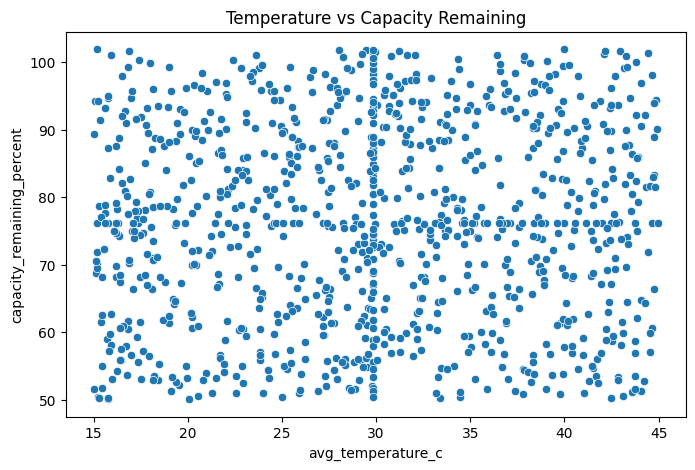

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='avg_temperature_c', y='capacity_remaining_percent', data=df)
plt.title("Temperature vs Capacity Remaining")
plt.show()


Step 3.4 — Correlation Heatmap

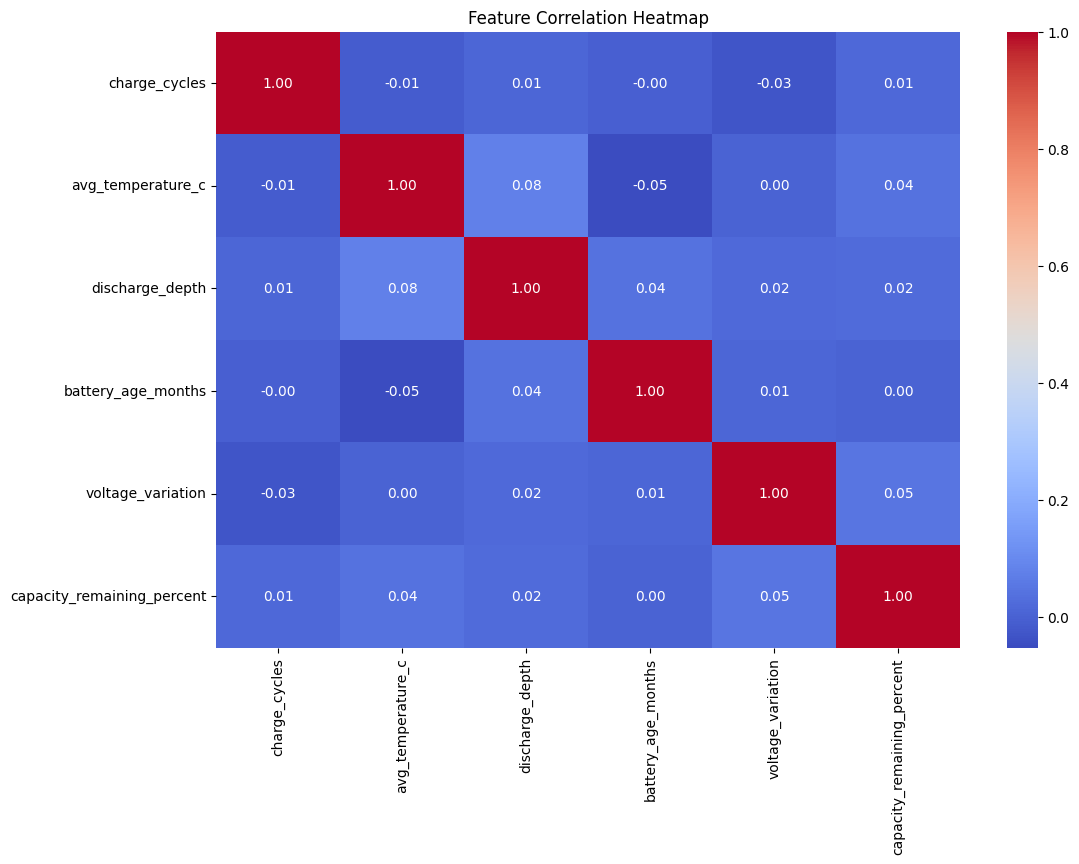

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


Step 3.5 — Battery Type vs Capacity

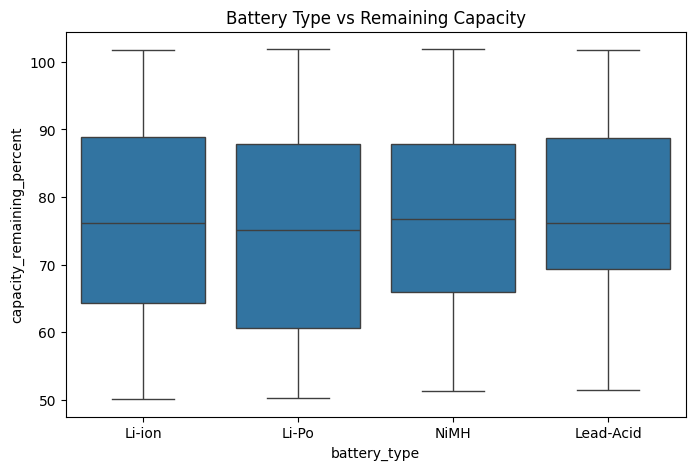

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x='battery_type', y='capacity_remaining_percent', data=df)
plt.title("Battery Type vs Remaining Capacity")
plt.show()


STEP 4 — REGRESSION MODELING

Predict exact battery degradation (% remaining capacity)

Step 4.1 — Feature Selection (Important)

In [20]:
features = ['charge_cycles', 'avg_temperature_c', 'charge_rate',
            'discharge_depth', 'battery_age_months', 'voltage_variation']

X = df[features]
y = df['capacity_remaining_percent']


Step 4.2 — Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


Step 4.3 — Feature Scaling (Very Important)

STEP 4.3 (FIXED) — CATEGORICAL ENCODING → THEN SCALING

Step 4.3.1 — Identify Categorical Columns

In [23]:
df.select_dtypes(include=['object']).columns


Index(['battery_type', 'charge_rate', 'cooling_system', 'manufacturer',
       'usage_pattern'],
      dtype='object')

Step 4.3.2 — Apply One-Hot Encoding

In [24]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,charge_cycles,avg_temperature_c,discharge_depth,battery_age_months,voltage_variation,capacity_remaining_percent,battery_type_Li-Po,battery_type_Li-ion,battery_type_NiMH,charge_rate_Medium,charge_rate_Slow,charge_rate_Superfast,cooling_system_Passive,manufacturer_B,manufacturer_C,manufacturer_D,manufacturer_E,usage_pattern_Mixed,usage_pattern_Performance,usage_pattern_Urban
0,994.000000,15.749784,83.043118,30.0,4.129414,87.278537,False,True,False,False,False,True,True,False,False,False,True,False,True,False
1,1053.684713,29.840542,62.135883,29.0,1.045002,55.291610,True,False,False,True,False,False,True,False,False,True,False,False,False,False
2,121.000000,38.216794,95.555966,10.0,1.709691,52.580032,False,True,False,False,False,True,True,False,False,False,True,False,True,False
3,427.000000,38.713143,67.144652,53.0,1.963543,69.824669,False,True,False,False,False,True,False,False,False,False,True,False,True,False
4,1569.000000,37.040177,61.831927,32.0,4.823389,76.207402,False,True,False,False,True,False,True,False,False,False,True,False,False,False


Step 4.3.3 — Redefine X and y from Encoded Data


In [25]:
X = df_encoded.drop('capacity_remaining_percent', axis=1)
y = df_encoded['capacity_remaining_percent']


Step 4.3.4 — Train-Test Split Again

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


Step 4.3.5 — Feature Scaling (Now It Will Work)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Regression Models
1.Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))


Linear Regression
MSE: 223.12202187153173
R2: -0.034120515742665836


Random Forest Regression

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Regression")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))


Random Forest Regression
MSE: 236.9101570206385
R2: -0.09802542890150057


SVR

In [30]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

print("SVR")
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("R2:", r2_score(y_test, y_pred_svr))


SVR
MSE: 221.6565914741204
R2: -0.027328574608193046


STEP 5 — CLASSIFICATION MODELING (Battery Health Class Prediction)

STEP 5.1 — Create Health Class Label

In [31]:
def health_label(cap):
    if cap >= 80:
        return "Good"
    elif cap >= 60:
        return "Medium"
    else:
        return "Poor"

df['health_class'] = df['capacity_remaining_percent'].apply(health_label)

df[['capacity_remaining_percent','health_class']].head()


,capacity_remaining_percent,health_class
0,87.278537,Good
1,55.291610,Poor
2,52.580032,Poor
3,69.824669,Medium
4,76.207402,Medium


STEP 5.2 — Encode Target Labels

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['health_class'] = le.fit_transform(df['health_class'])

df['health_class'].value_counts()


,count
health_class,
0,409
1,408
2,183


STEP 5.3 — Prepare Features (Use Encoded Dataset)

In [33]:
X_cls = df_encoded.drop('capacity_remaining_percent', axis=1)
y_cls = df['health_class']


STEP 5.4 — Train Test Split

In [34]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42)


STEP 5.5 — Scale Features

In [35]:
scaler_c = StandardScaler()

X_train_c = scaler_c.fit_transform(X_train_c)
X_test_c = scaler_c.transform(X_test_c)


STEP 5.6 — Decision Tree Classifier

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

dt = DecisionTreeClassifier()
dt.fit(X_train_c, y_train_c)

pred_dt = dt.predict(X_test_c)

print("Decision Tree Results")
print(classification_report(y_test_c, pred_dt))


Decision Tree Results
              precision    recall  f1-score   support

           0       0.50      0.46      0.48        84
           1       0.33      0.40      0.36        72
           2       0.29      0.23      0.25        44

    accuracy                           0.39       200
   macro avg       0.37      0.36      0.37       200
weighted avg       0.39      0.39      0.39       200



STEP 5.7 — Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_c = RandomForestClassifier(n_estimators=200)
rf_c.fit(X_train_c, y_train_c)

pred_rf = rf_c.predict(X_test_c)

print("Random Forest Classifier Results")
print(classification_report(y_test_c, pred_rf))


Random Forest Classifier Results
              precision    recall  f1-score   support

           0       0.43      0.39      0.41        84
           1       0.33      0.54      0.41        72
           2       0.50      0.05      0.08        44

    accuracy                           0.37       200
   macro avg       0.42      0.33      0.30       200
weighted avg       0.41      0.37      0.34       200



STEP 5.8 — SVM Classifier

In [38]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_c, y_train_c)

pred_svm = svm.predict(X_test_c)

print("SVM Results")
print(classification_report(y_test_c, pred_svm))


SVM Results
              precision    recall  f1-score   support

           0       0.41      0.38      0.40        84
           1       0.35      0.60      0.44        72
           2       0.00      0.00      0.00        44

    accuracy                           0.38       200
   macro avg       0.25      0.33      0.28       200
weighted avg       0.30      0.38      0.33       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


STEP 6 — NEURAL NETWORK CLASSIFICATION (Final Advanced Step)

STEP 6.1 — Import Deep Learning Libraries

In [39]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


STEP 6.2 — Build Neural Network Model

In [40]:
X_train_c.shape


(800, 19)

In [41]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_c.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


STEP 6.3 — Compile Model

In [42]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


STEP 6.4 — Train Model

In [43]:
history = model.fit(
    X_train_c,
    y_train_c,
    epochs=40,
    batch_size=16,
    validation_split=0.2
)


Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3874 - loss: 1.1465 - val_accuracy: 0.3562 - val_loss: 1.1183
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4431 - loss: 1.0885 - val_accuracy: 0.4062 - val_loss: 1.1010
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5021 - loss: 1.0319 - val_accuracy: 0.4062 - val_loss: 1.0894
Epoch 4/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4467 - loss: 1.0491 - val_accuracy: 0.3812 - val_loss: 1.0834
Epoch 5/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5010 - loss: 1.0265 - val_accuracy: 0.3938 - val_loss: 1.0836
Epoch 6/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4845 - loss: 1.0107 - val_accuracy: 0.3750 - val_loss: 1.0850
Epoch 7/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5016 - loss: 1.0044 - val_accuracy: 0.3625 - val_loss: 1.0887
Epoch 8/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5156 - loss: 0.9839 - val_accuracy: 0.3750 - val_loss

STEP 6.5 — Evaluate Model

In [44]:
loss, acc = model.evaluate(X_test_c, y_test_c)
print("Neural Network Accuracy:", acc)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3806 - loss: 1.3378
Neural Network Accuracy: 0.3700000047683716


STEP 6.6 — Predict Example Battery Health

In [45]:
sample = X_test_c[0].reshape(1, -1)

pred = model.predict(sample)

print("Predicted Class:", pred.argmax())
print("Health Label:", le.inverse_transform([pred.argmax()]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Predicted Class: 1
Health Label: ['Medium']


STEP 7 — MODEL COMPARISON & FINAL RESULT TABLE

STEP 7.1 — Regression Model Comparison Table

In [46]:
reg_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "SVR"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_svr)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_svr)
    ]
})

reg_results


,Model,R2 Score,MSE
0,Linear Regression,-0.034121,223.122022
1,Random Forest,-0.098025,236.910157
2,SVR,-0.027329,221.656591


STEP 7.2 — Classification Accuracy Comparison

In [47]:
from sklearn.metrics import accuracy_score

cls_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "SVM", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_test_c, pred_dt),
        accuracy_score(y_test_c, pred_rf),
        accuracy_score(y_test_c, pred_svm),
        acc
    ]
})

cls_results


,Model,Accuracy
0,Decision Tree,0.390
1,Random Forest,0.370
2,SVM,0.375
3,Neural Network,0.370


STEP 7.3 — Best Model Identification

In [48]:
print("Best Regression Model:",
      reg_results.sort_values("R2 Score", ascending=False).iloc[0]["Model"])

print("Best Classification Model:",
      cls_results.sort_values("Accuracy", ascending=False).iloc[0]["Model"])


Best Regression Model: SVR
Best Classification Model: Decision Tree


STEP 8 — FINAL PREDICTION PIPELINE FUNCTION 🔋⚡

STEP 8.1 — Save Training Feature Columns (VERY IMPORTANT)

In [49]:
feature_columns = X_cls.columns
feature_columns


Index(['charge_cycles', 'avg_temperature_c', 'discharge_depth',
       'battery_age_months', 'voltage_variation', 'battery_type_Li-Po',
       'battery_type_Li-ion', 'battery_type_NiMH', 'charge_rate_Medium',
       'charge_rate_Slow', 'charge_rate_Superfast', 'cooling_system_Passive',
       'manufacturer_B', 'manufacturer_C', 'manufacturer_D', 'manufacturer_E',
       'usage_pattern_Mixed', 'usage_pattern_Performance',
       'usage_pattern_Urban'],
      dtype='object')

STEP 8.2 — Create Final Prediction Function

In [50]:
import numpy as np
import pandas as pd

def predict_battery_health(input_dict):

    # convert to dataframe
    new_df = pd.DataFrame([input_dict])

    # apply same one-hot encoding
    new_df_encoded = pd.get_dummies(new_df)

    # align columns with training data
    new_df_encoded = new_df_encoded.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # scale
    new_scaled = scaler_c.transform(new_df_encoded)

    # classification prediction
    class_pred = model.predict(new_scaled).argmax()
    health = le.inverse_transform([class_pred])[0]

    # regression prediction
    deg_pred = rf.predict(new_scaled)[0]

    print("🔋 Predicted Remaining Capacity %:", round(deg_pred, 2))
    print("⚡ Predicted Health Class:", health)

    return deg_pred, health


STEP 8.3 — Test with Example Input

In [51]:
sample_input = {
    'charge_cycles': 450,
    'avg_temperature_c': 32,
    'charge_rate_Fast': 1,
    'charge_rate_Slow': 0,
    'discharge_depth': 70,
    'battery_age_months': 24,
    'voltage_variation': 0.15
}


In [52]:
predict_battery_health(sample_input)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
🔋 Predicted Remaining Capacity %: 78.0
⚡ Predicted Health Class: Medium


(np.float64(78.00040632872899), 'Medium')